In [1]:
# Tutorial for symbolic regression
# Based on the notebooks in https://github.com/JayWadekar/ScalingRelations_ML
# For the papers arXiv: 2209.02075 & 2201.01305

In [2]:
# We will be using the symbolic regression PySR by Miles Cranmer
# https://astroautomata.com/PySR/
# Please download PySR below in case you don't already have it
%pip install pysr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 1.9 MB/s eta 0:00:00a 0:00:01
  Using cached pandas-2.3.3-cp39-cp39-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.8 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 17.9 MB/s eta 0:00:0000:0100:01
  Using cached click-8.1.8-py3-none-any.whl (98 kB)
  Using cached numpy-2.0.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.5 MB)
  Using cached scikit_learn-1.6.1-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.5 MB)
  Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 16.8 MB/s eta 0:00:00
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Using cached scipy-1.13.1-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
  Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need 

In [4]:
%pip install numpy
%pip install matplotlib
%pip install sklearn
%pip install pysr



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Using cached matplotlib-3.9.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (8.3 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 2.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 11.9 MB/s eta 0:00:0000:0100:01
  Using cached contourpy-1.3.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (321 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached pillow-11.3.0-cp39-cp39-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.6 MB)

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need 

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Let us first try to reproduce a simple example
# Generate synthetic data using the function below

X = 2 * np.random.randn(100, 5)
y = 2.5382 * np.cos(X[:, 3]) + X[:, 0] ** 2 - 0.5


In [3]:
from pysr import PySRRegressor

model = PySRRegressor(
    maxsize=20,
    niterations=40,  # < Increase me for better results
    binary_operators=["+", "*"],
    unary_operators=[
        "cos",
        "exp",
        "sin",
        "inv(x) = 1/x",
        # ^ Custom operator (julia syntax)
    ],
    extra_sympy_mappings={"inv": lambda x: 1 / x},
    # ^ Define operator for SymPy as well
    elementwise_loss="loss(prediction, target) = (prediction - target)^2",
    # ^ Custom loss function (julia syntax)
)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [4]:
model.fit(X, y)

/mnt/c/Users/cenlo/scatter/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 1.000e+05
Progress: 564 / 1240 total iterations (45.484%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.627e+01  0.000e+00  y = 3.1414
3           3.178e+00  8.166e-01  y = x₀ * x₀
5           3.085e+00  1.491e-02  y = (x₀ * x₀) + -0.30554
6           1.279e+00  8.804e-01  y = (x₀ * x₀) + cos(x₃)
8           2.470e-01  8.222e-01  y = (x₀ * x₀) + (cos(x₃) * 2.4592)
11          3.673e-02  6.352e-01  y = ((x₀ * x₀) + (sin(cos(x₃)) * 3.0576)) + -0.38215
12          1.275e-13  2.639e+01  y = ((x₀ * x₀) + -0.010492) + ((cos(x₃) * 2.5382) + -0.489...
                                      51)
13          9.927e-14  2.506e-01  y = ((cos(x₃) + (cos(x₃) * 1.5382)) + (x₀ * x₀)) + -0.5
15          9.915e-14  6.015e-04  y = ((cos(x₃) + ((cos(x₃) + -0.06172)

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick      score                                           equation  \
	0          0.000000                                          3.1413543   
	1          0.816596                                            x0 * x0   
	2          0.014908                            (x0 * x0) + -0.30553916   
	3          0.880427                                (x0 * x0) + cos(x3)   
	4          0.822235                  (x0 * x0) + (cos(x3) * 2.4591618)   
	5   >>>>  14.206000  ((cos(x3) * 2.5382001) + -0.50000006) + (x0 * x0)   
	6          0.043736  (x0 * x0) + (((cos(x3) + -0.289128) * 2.538200...   
	7          0.046719  ((cos(x3) + (cos(x3) * 1.5382)) + -0.50000006)...   
	8          0.015560  ((x0 * x0) + -0.36200804) + ((cos(x3) + -0.137...   
	9          0.022536  ((inv(x3) * 5.219225e-9) + ((x0 * x0) + ((cos(...   
	10         0.113452  ((x0 * (x0 + (inv(cos(x4)) * -1.3491805e-8))) ...   
	
	            loss  complexity  
	0   1.627169e+01           1  
	1   3.177943e+00           3  
	2   3.084588e+00           5  
	3   1.278888e+00           6  
	4   2.469722e-01           8  
	5   1.131029e-13          10  
	6   1.036299e-13          12  
	7   9.889981e-14          13  
	8   9.586946e-14          15  
	9   8.960225e-14          18  
	10  7.999216e-14          19  
]

  - outputs/20260328_190113_KkYbwV/hall_of_fame.csv


In [5]:
model.equations_

,complexity,loss,equation,score,sympy_format,lambda_format
0,1,1.627169e+01,3.1413543,0.000000,3.14135430000000,PySRFunction(X=>3.14135430000000)
1,3,3.177943e+00,x0 * x0,0.816596,x0*x0,PySRFunction(X=>x0*x0)
2,5,3.084588e+00,(x0 * x0) + -0.30553916,0.014908,x0*x0 - 0.30553916,PySRFunction(X=>x0*x0 - 0.30553916)
3,6,1.278888e+00,(x0 * x0) + cos(x3),0.880427,x0*x0 + cos(x3),PySRFunction(X=>x0*x0 + cos(x3))
4,8,2.469722e-01,(x0 * x0) + (cos(x3) * 2.4591618),0.822235,x0*x0 + cos(x3)*2.4591618,PySRFunction(X=>x0*x0 + cos(x3)*2.4591618)
5,10,1.131029e-13,((cos(x3) * 2.5382001) + -0.50000006) + (x0 * x0),14.206000,x0*x0 + cos(x3)*2.5382001 - 0.50000006,PySRFunction(X=>x0*x0 + cos(x3)*2.5382001 - 0....
6,12,1.036299e-13,(x0 * x0) + (((cos(x3) + -0.289128) * 2.538200...,0.043736,x0*x0 + (cos(x3) - 0.289128)*2.5382001 + 0.233...,PySRFunction(X=>x0*x0 + (cos(x3) - 0.289128)*2...
7,13,9.889981e-14,((cos(x3) + (cos(x3) * 1.5382)) + -0.50000006)...,0.046719,x0*x0 + cos(x3) + cos(x3)*1.5382 - 0.50000006,PySRFunction(X=>x0*x0 + cos(x3) + cos(x3)*1.53...
8,15,9.586946e-14,((x0 * x0) + -0.36200804) + ((cos(x3) + -0.137...,0.015560,x0*x0 + cos(x3) + cos(x3)*1.5382 - 0.36200804 ...,PySRFunction(X=>x0*x0 + cos(x3) + cos(x3)*1.53...
9,18,8.960225e-14,((inv(x3) * 5.219225e-9) + ((x0 * x0) + ((cos(...,0.022536,x0*x0 + cos(x3) + cos(x3)*1.5382 - 0.49999997 ...,PySRFunction(X=>x0*x0 + cos(x3) + cos(x3)*1.53...


In [6]:
model.equations_.iloc[5]['equation']

'((cos(x3) * 2.5382001) + -0.50000006) + (x0 * x0)'

Text(0, 0.5, 'Loss')

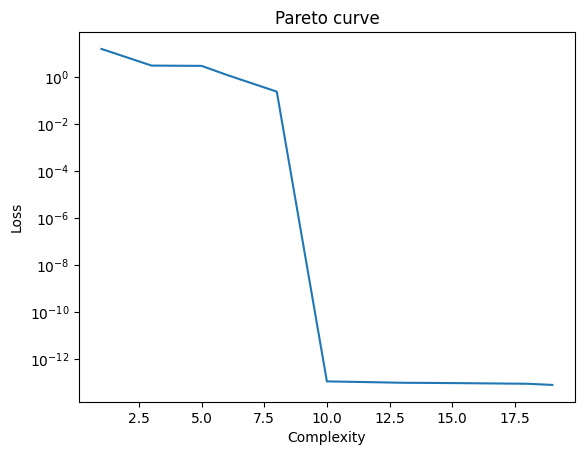

In [7]:
plt.semilogy(model.equations_['complexity'], model.equations_['loss'])
plt.title('Pareto curve')
plt.xlabel('Complexity')
plt.ylabel('Loss')

In [12]:
# Let us now move to our galaxy group/cluster dataset
# from arXiv:2209.02075

In [ ]:
# The data can be downloaded from https://drive.google.com/drive/folders/1GPLgNqfSUzcJKS4UxOewevg55ujIavOv?usp=sharingfrom google.colab import drive


# You need to give permission to access your local google drive if you run this notebook in colab
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !ls drive/MyDrive/'Shared data'

 Covariance	       'HM_Methods_2405.17400 '   HM_TemplateBanks   Y-M
 HM_Events_2312.06631   HM_pipeline		  SZ_RF


In [8]:
path = "arXiv_2209.02075_M__Mgas/" # My defined path for the data

In [9]:
powlaw=np.logspace(-10,30,num=5);
powlaw3=np.logspace(2,5.,num=15);
xh=0.76;

# Scaling Y from Leander's files
# 1e-6 * sigma_T / (me * c^2) * 1e10msun/h / Gyr^2
Yscale= 1e-6 * (6.65e-25) / (9.1e-28 * 3e10**2) * 1.989e43/0.671 / (3.154e16)**2

In [10]:
rbinEdges=np.append(0,np.geomspace(0.03, 2.5, num=128)) # radial bins in Leander's code
rbins = (rbinEdges[1:]+rbinEdges[:-1])/2
volBin=4/3.*np.pi*(rbinEdges[1:]**3-rbinEdges[:-1]**3)

def CumProfile(profiles_original, r200):
    profiles = profiles_original.copy()
    numHalos=len(profiles)

    for i in range(numHalos):
        profiles[i]*=r200[i]**3 * volBin *1e9

    cum_profiles = np.zeros((numHalos,128)); cum_profiles[:,0]=profiles[:,0]
    for i in range(1,128):
        cum_profiles[:,i]=profiles[:,i]+cum_profiles[:,i-1]

    return(cum_profiles)

In [11]:
dire=path+'SIMBA/LH'
os.chdir(dire)

In [12]:
m200=np.load('M200c.npy') # M200c (all masses are in units of 10^10 Msol/h)
r200=np.load('R200c.npy')/1e3 # R200c (in kpc/h)
yProf = np.load('y_profiles.npy'); # Profiles from Leander's code: y_prof.cpp
neProf = np.load('ne_profiles.npy'); # Profiles from Leander's code: ne_prof.cpp

In [13]:
# Indices corresponding to the simulation to which the halos belong
index=np.load('IndexFile.npy')

# Parameters of simulations
# Name  Omega_m  sigma_8  A_SN1  A_AGN1  A_SN2  A_AGN2  seed
params=np.loadtxt('./../CosmoAstroSeed.txt',usecols = (1,2,3,4,5,6))

params=params[index]

In [14]:
Y_rad = CumProfile(yProf,r200)*Yscale # scaled with 'Yscale' to get [Mpc^2] units
Y = Y_rad[:,101]*params[:,0] # Y200c
mGas_rad=CumProfile(neProf,r200); # Gas mass profile
GasConc = mGas_rad[:,80]/mGas_rad[:,101]; # Gas concentration
mGas = mGas_rad[:,101]*(2/(1+xh))*params[:,0]; # Gas mass within R200c * Omega_m

In [15]:
mStars=np.load('Mstar_cum_profile.npy')[:,101]*params[:,0] # stellar mass within R200c * Omega_m
mGas2=mGas_rad[:,80]*(2/(1+xh))*params[:,0]; # stellar mass within R200c/2 * Omega_m
mStars2=np.load('Mstar_cum_profile.npy')[:,80]*params[:,0] # gas mass within R200c/2 * Omega_m
# mBH=np.load('mBH.npy')[:,101]*params[:,0]
# Ngal=np.load('Richness.npy')

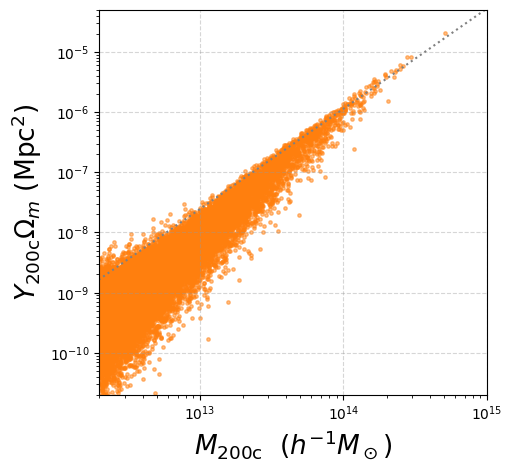

In [16]:
plt.figure(figsize=(5,5))

ax = plt.gca(); ax.set_yscale('log'); ax.set_xscale('log');
ax.scatter(m200*1e10,Y,alpha=.5,s=6,color='C1')
plt.grid(visible=True, which='major', color='#999999', linestyle='--',alpha=0.4)
ax.plot((powlaw**(3./5.))*3.7e17,powlaw,ls='dotted',color='gray')
plt.xlim(2e12,1e15); plt.ylim(2e-11,5e-5)
plt.xlabel(r'$M_\mathrm{200c}$'+'  ($h^{-1} M_\odot$)',fontsize=19); plt.ylabel(r'$Y_\mathrm{200c}\Omega_m \ (\mathrm{Mpc}^2)$',fontsize=19);

In [17]:
# Improving Y-M with machine learning
NormFactor = 4.5e22


M_over_Y= m200**(5./3.)*1e10/(Y*NormFactor) # Ratio in Eq. (5) of the paper

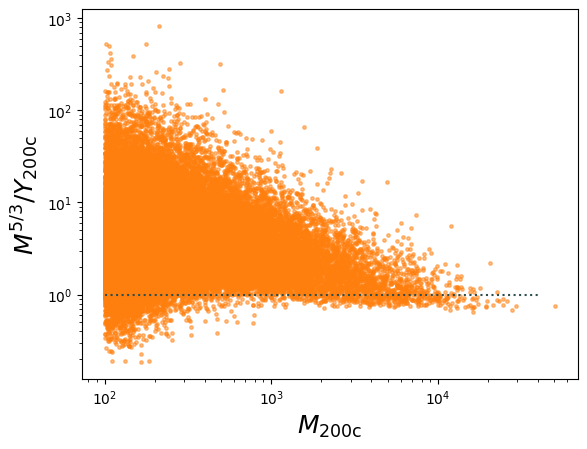

In [18]:
ax = plt.gca(); ax.set_xscale('log'); ax.set_yscale('log');
ax.scatter(m200 , M_over_Y, alpha=.5,s=6,color='C1')
ax.plot([1e2,4e4],[1,1],ls='dotted',color='darkslategray')
plt.ylabel(r'$M^{5/3}/Y_\mathrm{200c}$',fontsize=18); plt.xlabel(r'$M_\mathrm{200c}$',fontsize=18);

In [19]:
# We want to find M/Y = f(cluster properties)
# which will enable us to use Y * f(cluster properties) as a proxy for mass

In [20]:
# Input array to RF
inp = np.zeros((len(m200),7))
inp[:,0] = mGas;
inp[:,1] = mStars;
inp[:,2] = mGas2/mGas
inp[:,3] = mStars2/mStars
# inp[:,4] = T500;
# inp[:,5] = Ngal;
# inp[:,6] = Y
out = M_over_Y

In [21]:
maskTest = np.random.randint(len(inp),size=len(inp))>len(inp)/2


In [22]:
#Initializing RF
regr = RandomForestRegressor(max_depth=50, random_state=0,min_samples_leaf=5,n_estimators=50,n_jobs=-1)

#Fitting to training data
regr.fit(inp[~maskTest], np.log(out[~maskTest]),sample_weight=pow(m200,1/2)[~maskTest])

#Importance given by RF to each feature
print(regr.feature_importances_)


# We can compute the MSE here:
#metrics.mean_squared_error(regr.predict(inp[maskTest]),mtot[maskTest]/HODinv(Y)[maskTest])
# regrCopy = regr

[0.73482539 0.1277793  0.07688546 0.06050985 0.         0.
 0.        ]


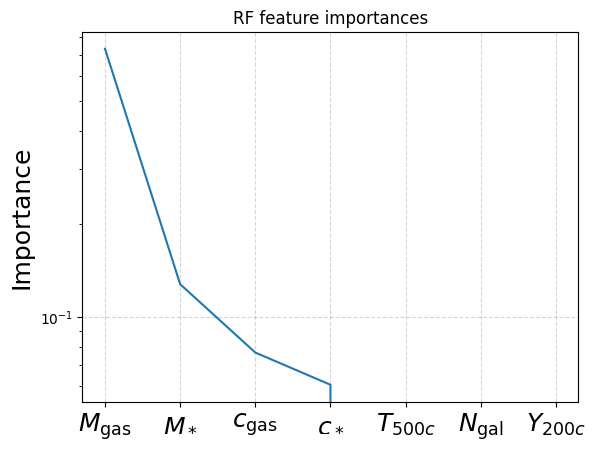

In [23]:
fig, ax = plt.subplots()# figsize=(8,4)
ax.semilogy(regr.feature_importances_[:7])
ax.set_xticks(np.arange(7));
ax.set_xticklabels([r'$M_\mathrm{gas}$', '$M_*$', '$c_\mathrm{gas}$', '$c_*$', '$T_{500c}$', '$N_\mathrm{gal}$', '$Y_{200c}$'],fontsize=18);
plt.title('RF feature importances')
ax.grid(visible=True, which='major', color='#999999', linestyle='--',alpha=0.4)
plt.ylabel('Importance',fontsize=18);
plt.show()

In [24]:
mRatio = np.exp(regr.predict(inp[maskTest]))/out[maskTest];

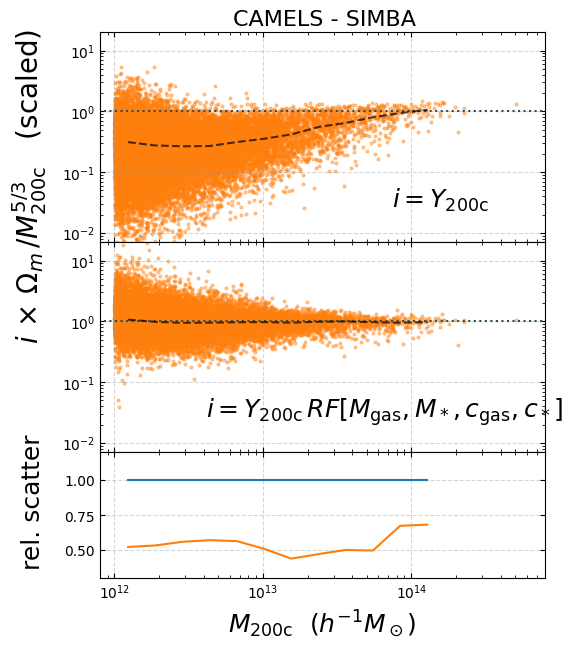

In [25]:
temp=np.logspace(12.,14.2,num=13);
_ = m200[maskTest]*1e10
meanY=np.zeros((2,len(temp)-1)); stdY=meanY.copy(); temp2=np.sqrt(temp[:-1]*temp[1:]);

for i in range(len(temp)-1):
    mask=(_>=temp[i])*(_<=temp[i+1])
    meanY[0,i]=np.median(1/out[maskTest][mask]); meanY[1,i]=np.median(mRatio[mask]);
    stdY[0,i]=np.std(np.log10(1/out[maskTest][mask])); stdY[1,i]=np.std(np.log10(mRatio[mask]));

fig = plt.figure(num=None, figsize=(5.3, 7))
fig.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
ax1 = fig.add_axes([0.15, 0.45, 0.84, 0.3], ylim=(7e-3,2e1),xlim=(.8e12,.8e15));
ax2 = fig.add_axes([0.15, 0.15, 0.84, 0.3], ylim=(7e-3,2e1),xlim=(.8e12,.8e15));
ax3 = fig.add_axes([0.15, -0.030, 0.84, 0.18], ylim=(0.3,1.2),xlim=(.8e12,.8e15));
ax1.set_xscale('log'); ax2.set_xscale('log'); ax3.set_xscale('log');
ax1.set_yscale('log'); ax2.set_yscale('log');
ax1.tick_params(axis="both",direction="in",which='both',right='true',top='true', labelbottom=0)
ax2.tick_params(axis="both",direction="in",which='both',right='true',top='true', labelbottom=0)
ax3.tick_params(axis="both",direction="in",which='both',right='true',top='true')
ax1.grid(visible=True, which='major', color='#999999', linestyle='--',alpha=0.4)
ax2.grid(visible=True, which='major', color='#999999', linestyle='--',alpha=0.4)
ax3.grid(visible=True, which='major', color='#999999', linestyle='--',alpha=0.4)

ax1.plot([1e10,1e18],[1,1],ls='dotted',color='darkslategray')
ax1.scatter(_,1/out[maskTest],alpha=.4,s=4,color='C1')
ax1.plot(temp2,meanY[0],'--',color='black',alpha=0.7)
ax2.plot([1e10,1e18],[1,1],ls='dotted',color='darkslategray')
ax2.scatter(_,mRatio,alpha=.4,s=4,color='C1')
ax2.plot(temp2,meanY[1],'--',color='black',alpha=0.7)
ax3.plot(temp2,np.ones(len(temp2))); ax3.plot(temp2,stdY[1]/stdY[0]);

fig.text(0.7, 0.5, "$i= Y_\mathrm{200c}$", rotation=0,fontsize=18)
# fig.text(0.35, 0.45, r"$\frac{M^{5/3}_\mathrm{pred}}{Y_\mathrm{200c}\Omega_m}\propto\, RF[Y,M_\mathrm{gas},M_*,M_\mathrm{BH},c_\mathrm{gas}]$", rotation=0,fontsize=16)
fig.text(0.35, 0.2, r"$i=Y_\mathrm{200c}\, RF[M_\mathrm{gas},M_*,c_\mathrm{gas},c_*]$", rotation=0,fontsize=18)
fig.text(-0.02, 0.32,r'$i\, \times\, \Omega_m\, /M^{5/3}_\mathrm{200c}$   (scaled)',fontsize=20,rotation=90);
fig.text(0, -0.01,'rel. scatter',fontsize=18,rotation=90);
plt.xlabel(r'$M_\mathrm{200c}$'+'  ($h^{-1} M_\odot$)',fontsize=18);
fig.text(0.4, .76, "CAMELS - SIMBA",fontsize=16)
plt.show()

In [26]:
# Let us now use symbolic regression
# Tip: choose dim. less quantities as inputs to the symbolic regression

inp = np.zeros((len(m200),4))
inp[:,0] = mStars/mGas
inp[:,1] = mStars2/mGas2
inp[:,2] = mStars2/mStars
inp[:,3] = mGas2/mGas

# I use M_halo**0.5 as weights
# (because there are comparative many more
# low-mass halos in the sample)
weights=pow(m200,1/2);

out = M_over_Y;

/tmp/ipykernel_49717/2736691691.py:6: RuntimeWarning: divide by zero encountered in divide
  inp[:,1] = mStars2/mGas2


In [27]:
# Downsampling low-mass halos to balance the dataset
ind=[]
for i in range(len(m200)):
    if(np.random.rand()<np.exp( (np.log10(m200[i])-3.7)/.4 )):
        ind.append(i)
ind=np.array(ind); print(ind.shape)

inp=inp[ind]; out=out[ind]; weights=weights[ind];

(3534,)


In [28]:
# Input variable names are
# mG: Mgas, mS: Mstars, mG2: Mgas within R200c/2
var_names = ['rSG', 'rSG2','cS', 'cG']


model = PySRRegressor(
    niterations=10,
    binary_operators=["+", "-", "*", "/",'pow'],
    unary_operators=["neg","exp","log10"],
    #denoise=True,
    procs=7,
    model_selection="best",
    elementwise_loss="loss(x, y, w) = abs(w * log(abs(x/y)))")

In [29]:
model.fit(inp, out, weights=weights, variable_names=(var_names))

/mnt/c/Users/cenlo/scatter/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/mnt/c/Users/cenlo/scatter/lib/python3.9/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.250e+04
Progress: 84 / 310 total iterations (27.097%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.810e-01  0.000e+00  y = -1.7442
3           3.086e-01  3.164e-01  y = rSG2 + 0.70419
5           2.940e-01  2.423e-02  y = (rSG2 ^ 0.84265) + 0.68119
6           2.859e-01  2.785e-02  y = cS - neg(-1.5653 - rSG2)
8           2.820e-01  7.013e-03  y = (neg(-1.5653 - rSG2) - cS) / -1.0388
9           2.746e-01  2.636e-02  y = (((cG ^ -0.93998) * 0.5463) + rSG2) * -0.64187
12          2.620e-01  1.562e-02  y = (rSG + rSG) + exp((cG / (cS - 1.3538)) + 0.55844)
13          2.605e-01  5.908e-03  y = neg(rSG + (rSG + exp((cG / (cS - 1.3098)) + 0.59154)))
14          2.583e-01  8.433e-03  y = neg(exp(neg((cG - 0.91973) + cG) - cG) + rSG) - rSG
20     

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                         -1.7454251   
	1  >>>>  0.316381                                   rSG2 + 0.7041909   
	2        0.041679                            (rSG2 - cS) + 1.5169512   
	3        0.003484            (-1.5652997 - (rSG2 - cS)) / -1.0387605   
	4        0.041860      rSG + ((0.3776092 / cG) * (rSG + 0.76114243))   
	5        0.001907  (cG ^ -0.8754043) * (((rSG * (cG ^ -0.72792244...   
	6        0.002647  (cG ^ -0.9899678) * (((rSG * ((cG ^ -0.4860723...   
	7        0.000978  exp(((cS * 1.697996) / (log10(rSG) - rSG2)) + ...   
	8        0.001075  neg((((cG ^ -0.68840927) * -1.4243358) + 0.006...   
	9        0.001219  neg(neg(neg(rSG - neg(rSG - (((((cG * (2.47315...   
	
	       loss  complexity  
	0  0.581041           1  
	1  0.308604           3  
	2  0.283922           5  
	3  0.281951           7  
	4  0.259307           9  
	5  0.257337          13  
	6  0.255979          15  
	7  0.254730          20  
	8  0.254183          22  
	9  0.252331          28  
]

  - outputs/20260328_190338_K4cvr3/hall_of_fame.csv


Text(0, 0.5, 'Loss')

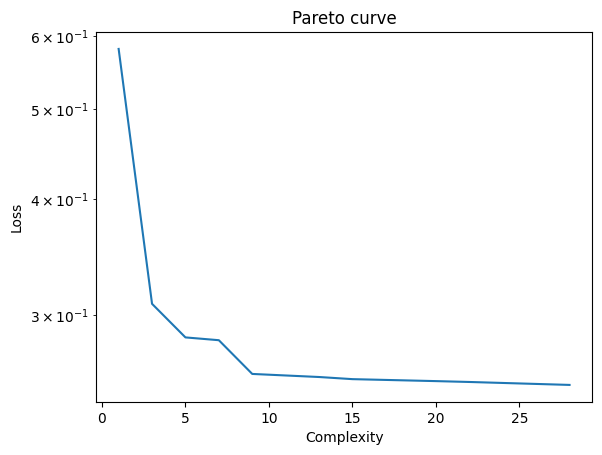

In [30]:
plt.semilogy(model.equations_['complexity'], model.equations_['loss'])
plt.title('Pareto curve')
plt.xlabel('Complexity')
plt.ylabel('Loss')

/tmp/ipykernel_49717/2713817183.py:2: RuntimeWarning: divide by zero encountered in divide
  new_ratio = mStars2/mGas2 + 0.71367


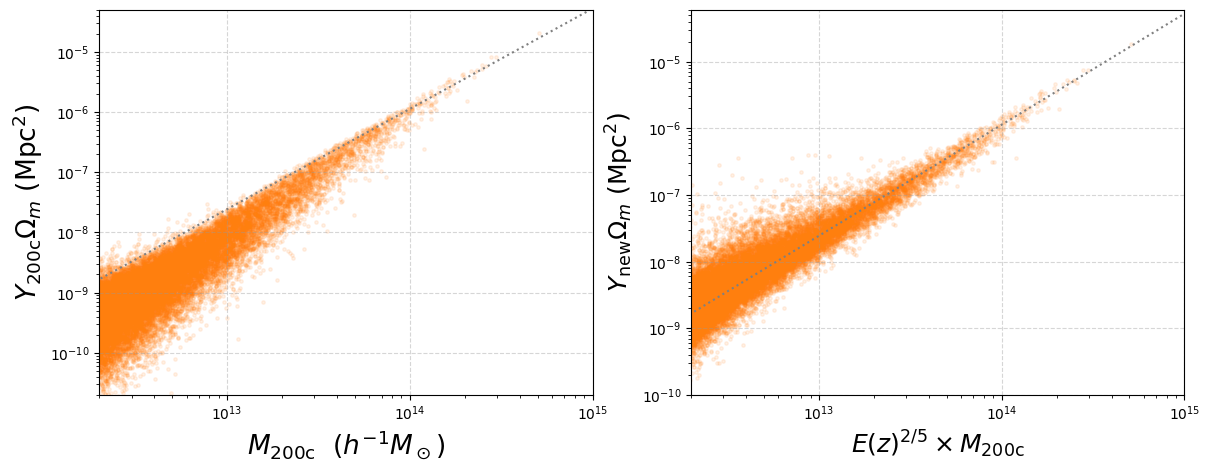

In [33]:
# The new equation works amazing!
new_ratio = mStars2/mGas2 + 0.71367
plt.figure(figsize=(14,5))

plt.subplot(121)
ax = plt.gca(); ax.set_yscale('log'); ax.set_xscale('log');
ax.scatter(m200*1e10,Y,alpha=.1,s=6,color='C1')
plt.grid(visible=True, which='major', color='#999999', linestyle='--',alpha=0.4)
ax.plot((powlaw**(3./5.))*3.7e17,powlaw,ls='dotted',color='gray')
plt.xlim(2e12,1e15); plt.ylim(2e-11,5e-5)
plt.xlabel(r'$M_\mathrm{200c}$'+'  ($h^{-1} M_\odot$)',fontsize=19); plt.ylabel(r'$Y_\mathrm{200c}\Omega_m \ (\mathrm{Mpc}^2)$',fontsize=19);

plt.subplot(122)
ax = plt.gca(); ax.set_yscale('log'); ax.set_xscale('log');
ax.scatter(m200*1e10,Y*new_ratio,alpha=.1,s=6,color='C1')
ax.plot((powlaw**(3./5.))*3.7e17,powlaw,ls='dotted',color='gray')
plt.grid(visible=True, which='major', color='#999999', linestyle='--',alpha=0.4)
plt.xlim(2e12,1e15); plt.ylim(1e-10,6e-5)
plt.xlabel(r'$E(z)^{2/5} \times M_\mathrm{200c}$',fontsize=18); plt.ylabel(r'$Y_\mathrm{new}\Omega_m\ (\mathrm{Mpc}^2)$',fontsize=18);